<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка данных</a></span><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Изучим-общую-информацию-о-датафреймах" data-toc-modified-id="Изучим-общую-информацию-о-датафреймах-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Изучим общую информацию о датафреймах</a></span></li><li><span><a href="#Проверим-данные-на-наличие-дубликатов" data-toc-modified-id="Проверим-данные-на-наличие-дубликатов-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Проверим данные на наличие дубликатов</a></span></li><li><span><a href="#Проверим-наличие-пропусков-в-данных" data-toc-modified-id="Проверим-наличие-пропусков-в-данных-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Проверим наличие пропусков в данных</a></span></li></ul></li><li><span><a href="#Ресемплирование-данных" data-toc-modified-id="Ресемплирование-данных-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Ресемплирование данных</a></span></li></ul></li><li><span><a href="#Анализ-данных" data-toc-modified-id="Анализ-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ данных</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Модель-LinearRegression()" data-toc-modified-id="Модель-LinearRegression()-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Модель LinearRegression()</a></span></li><li><span><a href="#Модель-DecisionTreeRegressor()" data-toc-modified-id="Модель-DecisionTreeRegressor()-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Модель DecisionTreeRegressor()</a></span></li><li><span><a href="#Модель-LGBMRegressor()" data-toc-modified-id="Модель-LGBMRegressor()-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Модель LGBMRegressor()</a></span></li><li><span><a href="#Модель-RandomForestRegressor()" data-toc-modified-id="Модель-RandomForestRegressor()-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Модель RandomForestRegressor()</a></span></li><li><span><a href="#Модель-CatBoostRegressor()" data-toc-modified-id="Модель-CatBoostRegressor()-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Модель CatBoostRegressor()</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span><ul class="toc-item"><li><span><a href="#Анализ-лучшей-модели" data-toc-modified-id="Анализ-лучшей-модели-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Анализ лучшей модели</a></span></li><li><span><a href="#Тестирование-лучшей-выбранной-модели" data-toc-modified-id="Тестирование-лучшей-выбранной-модели-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Тестирование лучшей выбранной модели</a></span></li></ul></li><li><span><a href="#Общий-вывод-по-исследованию" data-toc-modified-id="Общий-вывод-по-исследованию-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод по исследованию</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

**Импортируем и установим все необходимые библиотеки для исследования:**

(некоторые библиотеки могут установиться не с первого раза)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

RANDOM_STATE = 42
TEST_SIZE = 0.1
VAL_SIZE = 0.25

## Подготовка данных

### Загрузка данных

Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним в датафрейм.

In [2]:
taxi = pd.read_csv('/datasets/taxi.csv')

Выведем первые строки датафрейма, чтобы проверить, правильно ли считались данные:

In [3]:
taxi.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


Можно говорить о том, что CSV-файл считался правильно, и с ним можно работать.

### Предобработка данных

Изучим данные и сделаем выводы. 

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафрейме, выведем информацию о нем методом `.info()`:

In [4]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


Выведем размеры датафрейма:

In [5]:
taxi.shape

(26496, 2)

Из полученной информации видно, что необходимо привести тип данных столбца `'datetime'` к типу `datetime64`. Сделаем это:

In [6]:
taxi['datetime'] = taxi['datetime'].astype('datetime64')

In [7]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


Из повторной проверки видно, что тип данных изменился, а также обратим внимание, что количество ненулевых строк в столбцах соответствует общему количеству строк данных в датафрейме.

#### Проверим данные на наличие дубликатов

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [8]:
taxi.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет, что является весьма хорошим показателем.

В нашем случае проводить проверку на *неявные* дубликаты смысла нет, так как в датафрейме всего два столбца с данными и вероятность дубликатов крайне мала.

#### Проверим наличие пропусков в данных

Из вывода общей информации мы уже заметили, что пропусков в данных нет, но на всякий случай убедимся в этом.

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [9]:
taxi.isna().sum()

datetime      0
num_orders    0
dtype: int64

Из выводимой информации видим, что пропусков действительно нет, что тоже является хорошим показателем переданных нам данных.

### Ресемплирование данных

В связи с тем, что данные просят ресемплировать по часу, то выполним следующее:

Установим данные столбца `'datetime'` как индекс датафрейма.

In [10]:
taxi.set_index('datetime', inplace=True)

Отсортируем данные по новому индексу:

In [11]:
taxi.sort_index(inplace=True)

Проверим, в хронологическом ли порядке расположены даты и время. Воспользуемся атрибутом `.is_monotonic`. Если порядок соблюдён, атрибут вернёт `True`, если нет - `False`.

In [12]:
taxi.index.is_monotonic

True

Данные расположены в хронологическом порядке.

Теперь сделаем ресемплирование данных, как нам и указали в требованиях, по часу.

In [13]:
taxi = taxi.resample('1H').sum()

Построим график для наглядности:

Text(0.5, 1.0, 'График временного ряда исходных данных')

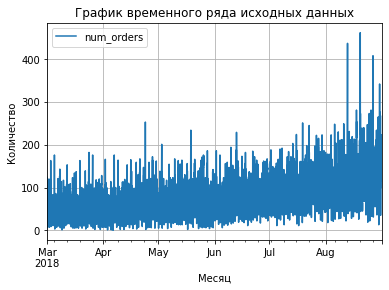

In [14]:
taxi.plot(grid=True)
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('График временного ряда исходных данных')

**Промежуточный вывод:**

В результате подготовки данных были выполнены следующие шаги:
- загрузили CSV-файл и проверили корректность его отображения
- изучили основную информацию о датафрейме
- определили, что тип данных не соответствует действительности и изменили его
- проверили данные на пропуски - выяснили, что они отсутствуют
- проверили и проанализировали данные на наличие дубликатов - выявили, что их нет
- сделали ресемплирование данных

## Анализ данных


Визуализируем временной ряд исходных данных:

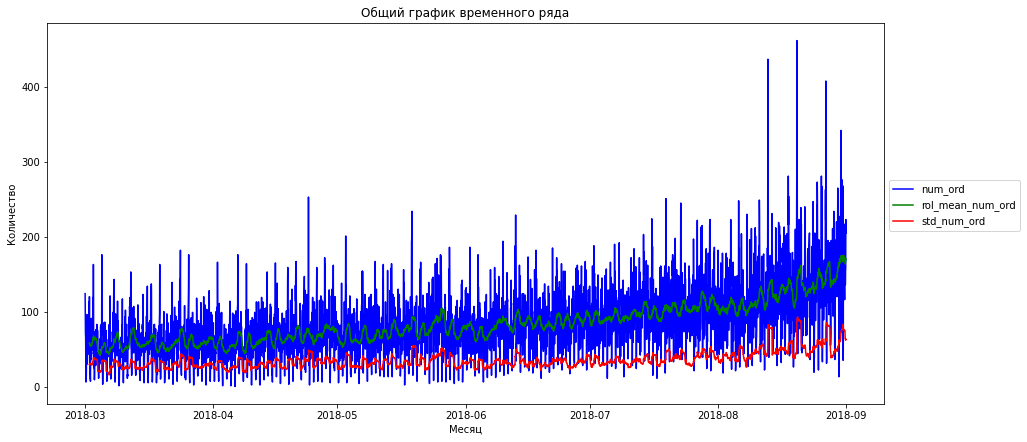

In [15]:
plt.figure(figsize=(15, 7))
plt.plot(taxi['num_orders'], color='blue')
plt.plot(taxi['num_orders'].rolling(25).mean(), color='green')
plt.plot(taxi['num_orders'].rolling(25).std(), color='red')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Общий график временного ряда')
plt.legend(['num_ord', 'rol_mean_num_ord','std_num_ord'], bbox_to_anchor=(1, 0.6))

График успешно построен, но сложен для проведения анализа, поэтому рассмотрим тренд, сезонность и остатки данных.

In [16]:
decomposed_taxi = seasonal_decompose(taxi) 

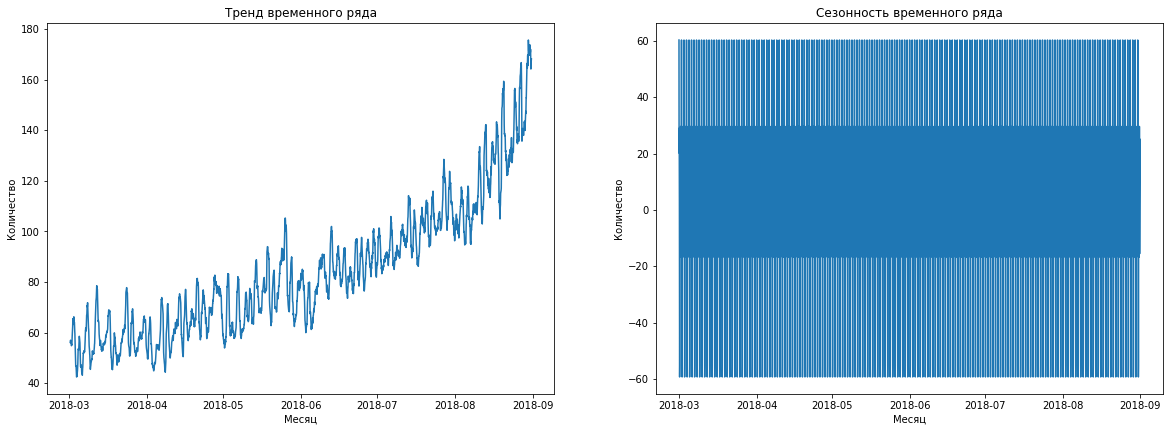

In [17]:
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
plt.plot(decomposed_taxi.trend)
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Тренд временного ряда')
plt.subplot(2, 2, 2)
plt.plot(decomposed_taxi.seasonal)
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Сезонность временного ряда')        
plt.show()

Из визуализированных графиков тренда и сезонности можно сказать следующее:
- Тренд возрастает по месяцам - можно предположить, что с наступлением весене-летнего периода спрос на такси увеличивается в связи с праздниками, отпусками, а также возможно из-за погоды, так как в случае ливня пользователю легче вызвать такси и добраться сухим, чем промокнуть
- Сезонность имеет очень "плотный" график, поэтому необходимо будет рассмотреть его более укрупненно (неделя и 3 дня)

Text(0.5, 1.0, 'Остатки временного ряда')

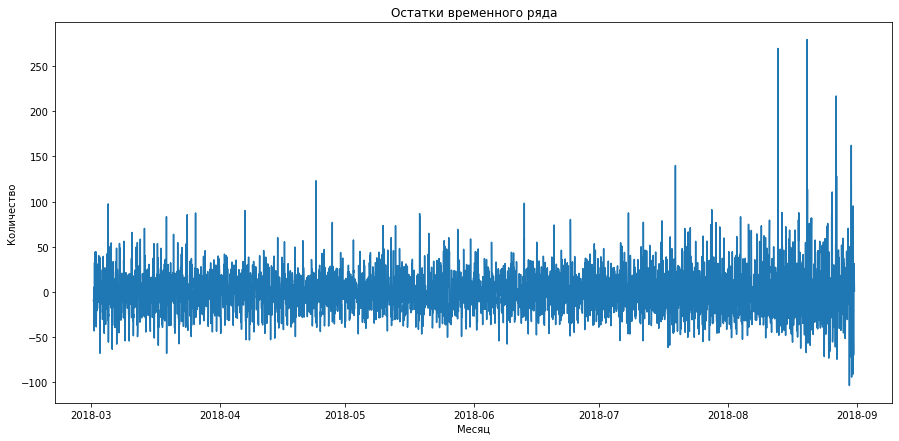

In [18]:
plt.figure(figsize=(15, 7))
plt.plot(decomposed_taxi.resid)
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Остатки временного ряда')     

Из графика видно, что значения колеблются около 0, что характерно для остатков временного ряда и большинство значений находятся в диапазоне от -50 до 50, что указывает на небольшие отклонения.

Text(0.5, 1.0, 'Сезонность временного ряда (неделя)')

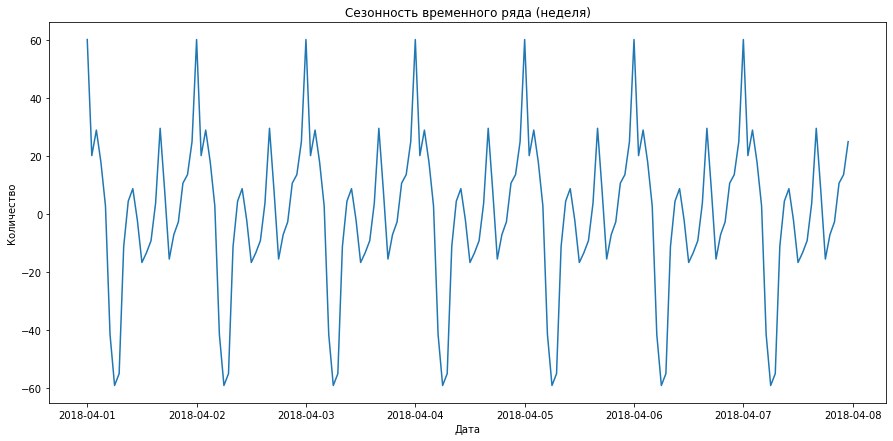

In [19]:
plt.figure(figsize=(15, 7))
plt.plot(decomposed_taxi.seasonal['2018-04-01':'2018-04-07'])
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Сезонность временного ряда (неделя)')     

Text(0.5, 1.0, 'Сезонность временного ряда (трое суток)')

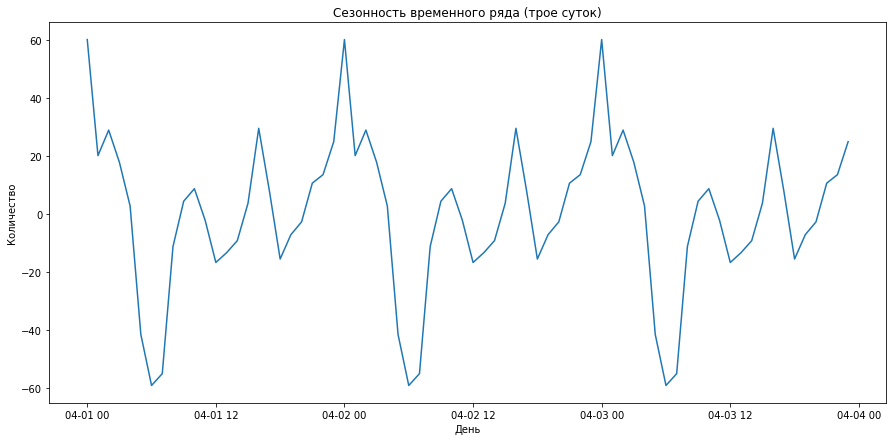

In [20]:
plt.figure(figsize=(15, 7))
plt.plot(decomposed_taxi.seasonal['2018-04-01':'2018-04-03'])
plt.xlabel('День')
plt.ylabel('Количество')
plt.title('Сезонность временного ряда (трое суток)') 

Text(0.5, 1.0, 'Сезонность временного ряда (сутки)')

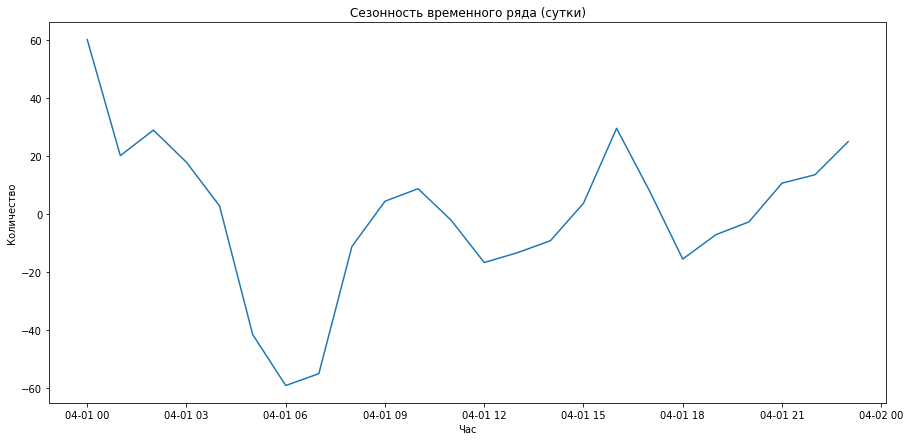

In [21]:
plt.figure(figsize=(15, 7))
plt.plot(decomposed_taxi.seasonal['2018-04-01'])
plt.xlabel('Час')
plt.ylabel('Количество')
plt.title('Сезонность временного ряда (сутки)') 

Из укрупненного графика можно говорить следующее:
- график сезонности похож на стохастический стационарный процесс 
- спрос на такси ночью минимален, а вот пики спроса (экстремумов) приходятся на рабочие часы и вечер: с 7 до 11, с 14 до 16 и с 18 до 12 ночи

**Промежуточный вывод:**

В результате анализа данных были выполнены следующие шаги:
- построили и проанализироавли график временного ряда данных
- рассмотрели графики тренда, сезонности и остатков временного ряда
- укрупнили график сезонности и проанализировали время минимального и максимального спросов

## Обучение

Перед обучением моделей проведём некоторые действия с данными.

Напишем функцию `make_features()` для создания признаков для наших данных:

In [22]:
def make_features(data, max_lag, rolling_mean_size):
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    data.dropna(inplace=True)
    return data

Создадим расширенный датафрейм с данными помощью написанной функции `make_features()`:

In [23]:
extended_taxi = make_features(taxi, 50, 50)

In [24]:
extended_taxi

,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_42,lag_43,lag_44,lag_45,lag_46,lag_47,lag_48,lag_49,lag_50,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-03 02:00:00,25,5,2,108.0,163.0,72.0,119.0,101.0,93.0,49.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,62.82
2018-03-03 03:00:00,64,5,3,25.0,108.0,163.0,72.0,119.0,101.0,93.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,60.84
2018-03-03 04:00:00,44,5,4,64.0,25.0,108.0,163.0,72.0,119.0,101.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,60.42
2018-03-03 05:00:00,15,5,5,44.0,64.0,25.0,108.0,163.0,72.0,119.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,59.88
2018-03-03 06:00:00,9,5,6,15.0,44.0,64.0,25.0,108.0,163.0,72.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,58.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 19:00:00,136,4,19,207.0,217.0,197.0,116.0,133.0,166.0,136.0,...,217.0,216.0,265.0,177.0,170.0,191.0,169.0,120.0,159.0,169.64
2018-08-31 20:00:00,154,4,20,136.0,207.0,217.0,197.0,116.0,133.0,166.0,...,232.0,217.0,216.0,265.0,177.0,170.0,191.0,169.0,120.0,169.18
2018-08-31 21:00:00,159,4,21,154.0,136.0,207.0,217.0,197.0,116.0,133.0,...,193.0,232.0,217.0,216.0,265.0,177.0,170.0,191.0,169.0,169.86


Разделим данные на тренировочную, валидационную и тестовую выборки.

Это необходимо, так как на валидационной выборке будет проводиться расчёт по поискку лучших гиперпараметров.

In [25]:
# Деление и сохранение данных на тестовую и временную выборки
X_temp, X_test, y_temp, y_test = train_test_split(extended_taxi.drop(['num_orders'], axis=1), 
                                                  extended_taxi['num_orders'], 
                                                  shuffle=False,
                                                  test_size=TEST_SIZE, 
                                                  random_state=RANDOM_STATE)

In [26]:
# Деление временной выборки на тренировочную и валидационную выборки
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, 
                                                      y_temp, 
                                                      shuffle=False,
                                                      test_size=VAL_SIZE, 
                                                      random_state=RANDOM_STATE)

In [27]:
# Размеры тренировочнойб валидационной и тестовой выборкок
X_train.shape, X_valid.shape, X_test.shape

((2946, 53), (983, 53), (437, 53))

Перед работой с разными моделями создадим списки, куда будем записывать их результаты, чтобы после было проще проанализировать и сравнить данные: 

In [28]:
# Создаем пустые списки для таблицы результатов 
models = []
rmse_result_valid = []
rmse_result_test = []

Для дальнейшей оптимизации кода и избежания его повторения напишем функцию, для обучения и предсказания модели, а также вычисления метрики RMSE:

In [29]:
def ml_model(model):
    # Инициализируем модель
    chosen_model = model
    models.append(chosen_model)
    
    # Обучим модель на тренировочных данных
    chosen_model.fit(X_train, y_train)
    
    # Получим предсказания модели на валидационных данных 
    # и сохраним результат в y_pred_chosen_model
    y_pred_chosen_model = chosen_model.predict(X_valid)
    
    # Вычисление RMSE
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_chosen_model))
    print('Метрика RMSE для модели', chosen_model, ' :', round(rmse,5))
    rmse_result_valid.append(rmse)

### Модель LinearRegression()

Рассмотрим одну и наиболее часто применимых моделей за весь наш курс - LinearRegression():

Применим ранее написанную функцию `ml_model`:

In [30]:
ml_model(LinearRegression())

Метрика RMSE для модели LinearRegression()  : 29.69209


В результате видно, что значение метрики RMSE получилось вполне хорошее, так как по условию заказчика, метрика должна быть менее `48`.   

### Модель DecisionTreeRegressor()

Рассмотрим следующую модель для обучения `DecisionTreeRegressor()`; к ней также применим функцию `ml_model`:

In [31]:
ml_model(DecisionTreeRegressor(random_state=RANDOM_STATE))

Метрика RMSE для модели DecisionTreeRegressor(random_state=42)  : 40.19228


Полученный результат метрики RMSE уже хуже, но удовллетворяет требованию быть меньше 48.

Теперь постараемся подобрать гиперпараметры для улучшения метирки RMSE. Рассмотрим модель `DecisionTreeRegressor()` с гипермараметрами:
- `max_depth` - максимальная глубина дерева

In [32]:
for depth in range(5, 20):
    research_model = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth = depth)
    research_model.fit(X_train, y_train)
    y_pred_research_model = research_model.predict(X_valid)
    
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_research_model))
    print('Гиперпараметр depth:', depth)
    print('Метрика RMSE для исследуемой модели DecisionTreeRegressor():', round(rmse,5), '\n')
print()

Гиперпараметр depth: 5
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 34.19079 

Гиперпараметр depth: 6
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 35.14114 

Гиперпараметр depth: 7
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 34.55408 

Гиперпараметр depth: 8
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 35.25986 

Гиперпараметр depth: 9
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 36.61953 

Гиперпараметр depth: 10
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 38.30141 

Гиперпараметр depth: 11
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 38.30823 

Гиперпараметр depth: 12
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 39.07857 

Гиперпараметр depth: 13
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 39.94354 

Гиперпараметр depth: 14
Метрика RMSE для исследуемой модели DecisionTreeRegressor(): 40.33099 

Гиперпараметр depth: 15
Метрика RMSE для иссл

Из результата поиска по подбору гиперпараметра `max_depth` видно, что результат при значении `5` сильно улучшился по сравнению с ранее полученной метрикой RMSE. Поэтому для анализа будем рассматривать модель, в которой гиперпараметры улучшили модель. 

In [33]:
ml_model(DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE))

Метрика RMSE для модели DecisionTreeRegressor(max_depth=5, random_state=42)  : 34.19079


### Модель LGBMRegressor()

Рассмотрим модель LGBMRegressor(). В связи с некоторыми особенностями, нам бы пришлось изменять категориальные переменные в датафрейме, но так как таких данных у нас нет, то проделаем аналогичные действия:

In [34]:
ml_model(lgb.LGBMRegressor(random_state = RANDOM_STATE))

Метрика RMSE для модели LGBMRegressor(random_state=42)  : 29.49901


Результат вполне удовлетворяет условию.

Попробуем подобрать возможные гиперпараметры для улучшения метрики RMSE:

In [35]:
param_grid = {'max_depth': [5,7,9], 'n_estimators': [100, 250, 500, 750]}

С помощью GridSearchCV осуществим поиск лучших гиперпараметров:

In [36]:
lgbm_model = lgb.LGBMRegressor(random_state = RANDOM_STATE)
research = GridSearchCV(
        lgbm_model,
        param_grid,
        n_jobs=-1,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=3
        )

# обучение модели
research.fit(X_train, y_train)
print('Лучшие подобранные гиперпараметры исследованных моделей:', research.best_params_)
print('Лучшая метрика RMSE исследованных моделей:', (-1) * research.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END ..................max_depth=5, n_estimators=100; total time= 2.0min
[CV 2/3] END ..................max_depth=5, n_estimators=100; total time=   1.7s
[CV 3/3] END ..................max_depth=5, n_estimators=100; total time=  18.2s
[CV 1/3] END ..................max_depth=5, n_estimators=250; total time=  28.6s
[CV 2/3] END ..................max_depth=5, n_estimators=250; total time=  33.0s
[CV 3/3] END ..................max_depth=5, n_estimators=250; total time=   1.7s
[CV 1/3] END ..................max_depth=5, n_estimators=500; total time=   2.8s
[CV 2/3] END ..................max_depth=5, n_estimators=500; total time=   2.8s
[CV 3/3] END ..................max_depth=5, n_estimators=500; total time=   3.0s
[CV 1/3] END ..................max_depth=5, n_estimators=750; total time=   4.8s
[CV 2/3] END ..................max_depth=5, n_estimators=750; total time=   3.9s
[CV 3/3] END ..................max_depth=5, n_es

После выполнения мы получили следующие лучшие гиперпараметры `'max_depth'`: `5`, `'n_estimators'`: `100`; и следующее значение метрики RMSE - `21.15882`. При сравнении с результатом метрики в модели с гиперпараметрами по умолчанию можно сказать, что результат отличается друг от друга. В связи с этим при сравнении моделей будем рассматривать модель `LGBMRegressor()` с найденными гиперпараметрами. 

In [37]:
ml_model(lgb.LGBMRegressor(max_depth=5, n_estimators=100, random_state=42))

Метрика RMSE для модели LGBMRegressor(max_depth=5, random_state=42)  : 29.40369


### Модель RandomForestRegressor()

Рассмотрим модель `RandomForestRegressor()`:

In [38]:
ml_model(RandomForestRegressor(random_state=RANDOM_STATE))

Метрика RMSE для модели RandomForestRegressor(random_state=42)  : 30.17784


Попробуем подобрать для модели `RandomForestRegressor()` гипермараметр:
- `max_depth` - максимальная глубина дерева

In [39]:
for depth in range(5, 15):
        research_model = RandomForestRegressor(random_state=RANDOM_STATE, max_depth = depth)
        research_model.fit(X_train, y_train)
        y_pred_research_model = research_model.predict(X_valid)
                
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred_research_model))
        print('Гиперпараметр depth:', depth)
        print('Метрика RMSE для исследуемой модели RandomForestRegressor():', round(rmse,5), '\n')
print()

Гиперпараметр depth: 5
Метрика RMSE для исследуемой модели RandomForestRegressor(): 32.30197 

Гиперпараметр depth: 6
Метрика RMSE для исследуемой модели RandomForestRegressor(): 31.4829 

Гиперпараметр depth: 7
Метрика RMSE для исследуемой модели RandomForestRegressor(): 31.03297 

Гиперпараметр depth: 8
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.71746 

Гиперпараметр depth: 9
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.57278 

Гиперпараметр depth: 10
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.38577 

Гиперпараметр depth: 11
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.2026 

Гиперпараметр depth: 12
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.34247 

Гиперпараметр depth: 13
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.14195 

Гиперпараметр depth: 14
Метрика RMSE для исследуемой модели RandomForestRegressor(): 30.1569 




Как видно при поиске лучших гиперпараметров модель `RandomForestRegressor()` не сильно улучшила результат метрики RMSE, поэтому оставим для дальнейшего сравнения модель с набором гиперпарметров по умолчанию.

### Модель CatBoostRegressor()

Теперь рассмотрим модель `CatBoostRegressor()`:

In [40]:
ml_model(CatBoostRegressor(random_state=RANDOM_STATE, verbose=False))

Метрика RMSE для модели <catboost.core.CatBoostRegressor object at 0x7eff9e91a610>  : 29.49526


Результат полученной метрики модели вполне удовлетворяет условию быть меньше `48`.

Запишем в `datatable` результаты проведенных исследований:

In [41]:
# данные об исследованных моделях
datatable = {
    'model': models,
    'rmse_result_valid': rmse_result_valid,
}

Преобразуем теперь данные в датафрейм:

In [42]:
result_table = pd.DataFrame(datatable)
result_table

,model,rmse_result_valid
0,LinearRegression(),29.692091
1,DecisionTreeRegressor(random_state=42),40.192277
2,"DecisionTreeRegressor(max_depth=5, random_stat...",34.190789
3,LGBMRegressor(random_state=42),29.499007
4,"LGBMRegressor(max_depth=5, random_state=42)",29.403689
5,"(DecisionTreeRegressor(max_features='auto', ra...",30.177844
6,<catboost.core.CatBoostRegressor object at 0x7...,29.495256


Датафрейм успешно сформирован.

**Промежуточный вывод:**

В результате обучения моделей было выполнено и получено следующее:
- выбраны модели для обучения: `LinearRegression()`, `DecisionTreeRegressor()`, `LGBMRegressor()`, `RandomForestRegressor()`, `CatBoostRegressor()`
- данные разбиты на тренировочную, валидационную и тестовую выборки
- проведено обучение и предсказание для моделей
- вычислено значение метрики RMSE
- проведен поиск лучших гиперпараметров для моделей
- сформирован датафрейм с результатами исследования моделей

## Тестирование

### Анализ лучшей модели

Исходя из полученных результатов по разным моделям, выберем лучшую из них для проверки на тестовых данных. В условиях было сказано, что необходимо, чтобы значение метрики RMSE на *тестовой* выборке должно быть не больше `48`. На валидационной это условие было выполнено у всех моделей.

Отсортируем ранее сформированный датафрейм с данными по убыванию, чтобы рассмотреть самые лучшие значения метрик RMSE:

In [43]:
result_table.sort_values(by='rmse_result_valid')

,model,rmse_result_valid
4,"LGBMRegressor(max_depth=5, random_state=42)",29.403689
6,<catboost.core.CatBoostRegressor object at 0x7...,29.495256
3,LGBMRegressor(random_state=42),29.499007
0,LinearRegression(),29.692091
5,"(DecisionTreeRegressor(max_features='auto', ra...",30.177844
2,"DecisionTreeRegressor(max_depth=5, random_stat...",34.190789
1,DecisionTreeRegressor(random_state=42),40.192277


Видно, что в тройке лучших модели:
- `LGBMRegressor(max_depth=5, random_state=42)` - `29.403689`
- `CatBoostRegressor()` - `29.495256`
- `LinearRegression()` - `29.692091`

Как можно заметить, все эти результаты отличаются на несколько десятых.

Самая лучшаяя метрика получилась у модели `LGBMRegressor(max_depth=5, random_state=42)`, но и `CatBoostRegressor()` тоже близка к ней(отличие в сотых), однако это может быть результатом переобучения на тренировочной выборке. В связи с этим выберем лучшей моделью - модель `LinearRegression()`, и на ней проверим результаты тестовой выборки.

### Тестирование лучшей выбранной модели

Проведем тестирование лучшей модели - `LinearRegression()`:

In [44]:
# Инициализируем модель
lin_model = LinearRegression()

In [45]:
# Обучим модель на тренировочных данных
lin_model.fit(X_train, y_train)

LinearRegression()

In [46]:
# Получим предсказания модели на тестовых данных 
# и сохраним результат в y_pred_lin_model
y_pred_lin_model = lin_model.predict(X_test)

In [47]:
# Вычисление RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin_model))
print('Метрика RMSE на тестовых данных для модели', lin_model, ' :', round(rmse,5))

Метрика RMSE на тестовых данных для модели LinearRegression()  : 43.01149


Из результата вывода значения метрики RMSE видно, что оно много выше, чем на валидационных данных, однако всё равно условие заказчика было выполнено - значение метрики RMSE не больше `48`. Поэтому можно говорить о том, что модель справилась успешно.

Визуализируем данные.

Для этого объединим тестовые и предсказанные данные для упрощения построения графика временных рядов:

In [48]:
final_results = pd.DataFrame(y_test)

In [49]:
final_results['predictions'] = y_pred_lin_model

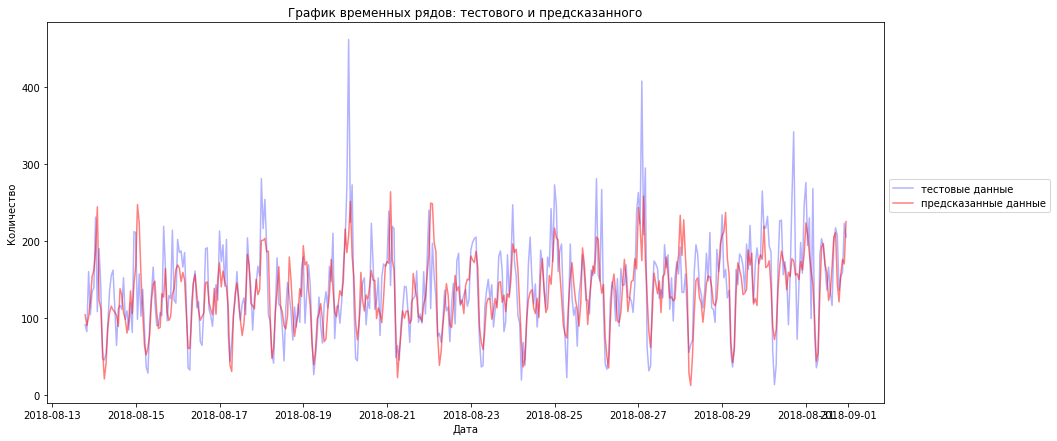

In [50]:
# график временных рядов
plt.figure(figsize=(15, 7))
plt.plot(final_results.index, final_results['num_orders'], color='blue', alpha=0.3, label='тестовые данные')
plt.plot(final_results.index, final_results['predictions'], color='red', alpha=0.5, label='предсказанные данные')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('График временных рядов: тестового и предсказанного')
plt.legend( bbox_to_anchor=(1, 0.6))
plt.show()

Из графика также видно, что в основном модель справляется с правильным предсказанием.

## Общий вывод по исследованию

Сформулируем общий вывод из проведенного нами исследования:

- Загрузка данных:
    - считали CSV-файл и проверили корректность его отображения 
- Предобработка данных:
    - изучили основную информацию о датафрейме
    - определили, что тип данных не соответствует действительности и изменили его
    - проверили данные на пропуски - выяснили, что они отсутствуют
    - проверили и проанализировали данные на наличие дубликатов - выявили, что их нет
- Ресемплирование данных:
    - сделали ресемплирование данных

- Анализ данных:
    - построили и проанализироавли график временного ряда данных
    - рассмотрели графики тренда, сезонности и остатков временного ряда
    - укрупнили график сезонности и проанализировали время минимального и максимального спросов: спрос на такси ночью минимален, а вот пики спроса (экстремумов) приходятся на рабочие часы и вечер: с 9 до 12 дня, с 14 до 16 и с 18 до 12 ночи

- Обучение моделей:
    - написали функцию для создания новых признаков
    - разделили данные на входные и целевые признаки для тренировочных, валидационных и тестовых данных
    - проверили размеры данных(строки, столбцы)

Для обучения моделей рассматривались модели:
- `LinearRegression()`
- `DecisionTreeRegressor()`
- `LGBMRegressor()`
- `RandomForestRegressor()`
- `CatBoostRegressor()`

Согласно поставленным нам критериям были получены следующие модели, которые справились лучше всего с ним:
- метрика качества предсказания у моделей (RMSE):
    - модель `LGBMRegressor(max_depth=5, random_state=42)` - `29.403689`
    - модель `CatBoostRegressor()` - `29.495256`
    - модель `LinearRegression()` - `29.692091`

Данные результаты отличаются на несколько десятых. 

Из проведенного анализа метрик RMSE, переборе разных гипермараметров в моделях самая лучшая метрика получилась у модели `LGBMRegressor(max_depth=5, random_state=42)` и результатом метрики RMSE на валидационных данных `29.403689` , что удовлетворяет требованию быть меньше `48`; однако это может быть результатом переобучения на тренировочной выборке. В связи с этим выберем лучшей моделью - модель `LinearRegression()`. 

При проверки тестовой выборки на лучшей модели - `LinearRegression()` - был получен результат метрики RMSE `43.01149`. Данный результат больше, чем на валидационных данных, но он *удовлетворяет* условию заказчика быть меньше `48`. Исходя из полученного результата, компании рекомендуется использовать данную модель для прогнозирования количества заказов такси на следующий час.

## Чек-лист проверки

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Данные загружены и подготовлены
- [x]  Данные проанализированы
- [x]  Модель обучена, гиперпараметры подобраны
- [x]  Качество моделей проверено, выводы сделаны
- [x]  Значение *RMSE* на тестовой выборке не больше 48